/tmp/ipykernel_1238/203892935.py:44: RuntimeWarning: overflow encountered in matmul
  gradient = A.T @ (A @ x - b)
/tmp/ipykernel_1238/203892935.py:48: RuntimeWarning: invalid value encountered in matmul
  residual = np.linalg.norm(A @ x - b)
/tmp/ipykernel_1238/203892935.py:44: RuntimeWarning: invalid value encountered in matmul
  gradient = A.T @ (A @ x - b)


Results
----------------------------------------
Condition Number : 2.7311
Iterations       : 1000
Residual Norm    : nan
Relative Error   : nan
Execution Time   : 0.025445 seconds


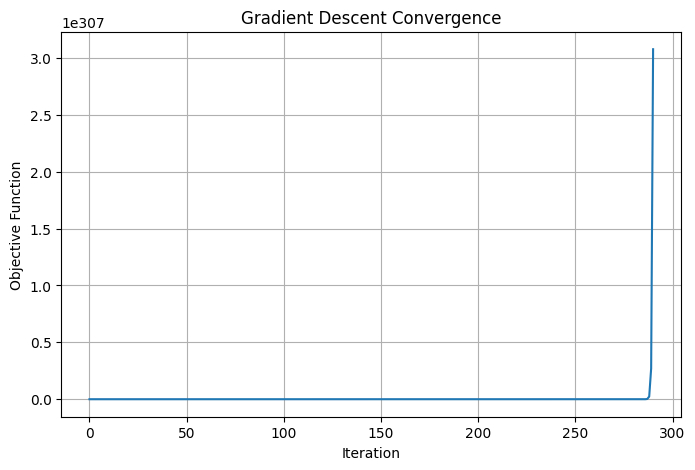

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# -----------------------------
# Generate Synthetic Dataset
# -----------------------------

np.random.seed(42)

m = 200
n = 50

A = np.random.randn(m, n)

x_true = np.random.randn(n)

b = A @ x_true

# -----------------------------
# Gradient Descent Parameters
# -----------------------------

alpha = 0.01

max_iterations = 1000

tolerance = 1e-6

x = np.zeros(n)

loss_history = []

residual_history = []

# -----------------------------
# Gradient Descent
# -----------------------------

start_time = time.time()

for iteration in range(max_iterations):

    gradient = A.T @ (A @ x - b)

    x = x - alpha * gradient

    residual = np.linalg.norm(A @ x - b)

    loss = 0.5 * residual**2

    loss_history.append(loss)

    residual_history.append(residual)

    if residual < tolerance:
        break

end_time = time.time()

# -----------------------------
# Performance Metrics
# -----------------------------

runtime = end_time - start_time

relative_error = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)

condition_number = np.linalg.cond(A)

print("Results")
print("-"*40)
print(f"Condition Number : {condition_number:.4f}")
print(f"Iterations       : {iteration+1}")
print(f"Residual Norm    : {residual:.6e}")
print(f"Relative Error   : {relative_error:.6e}")
print(f"Execution Time   : {runtime:.6f} seconds")

# -----------------------------
# Convergence Plot
# -----------------------------

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Objective Function")
plt.title("Gradient Descent Convergence")
plt.grid(True)
plt.show()

Gradient Descent Configuration
Matrix Size                : 200 x 50
Largest Eigenvalue (L)     : 437.714945
Learning Rate (alpha)      : 0.00228459

Converged after 111 iterations.


Experimental Results
Condition Number           : 2.731138
Iterations                 : 111
Residual Norm              : 9.82176877e-07
Relative Error             : 2.05887057e-08
Execution Time (seconds)   : 0.004869


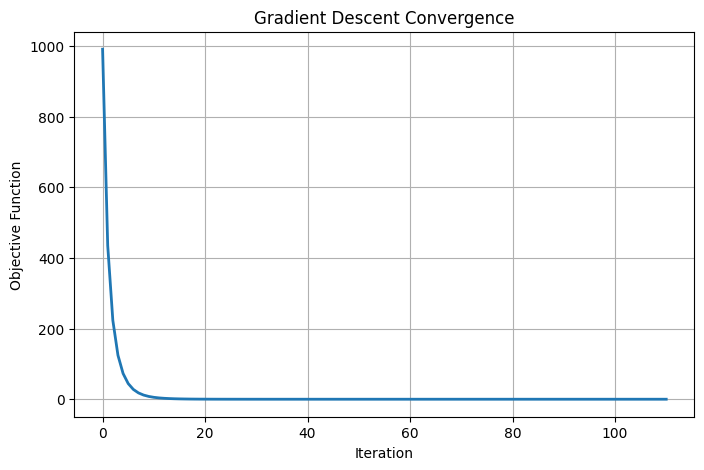

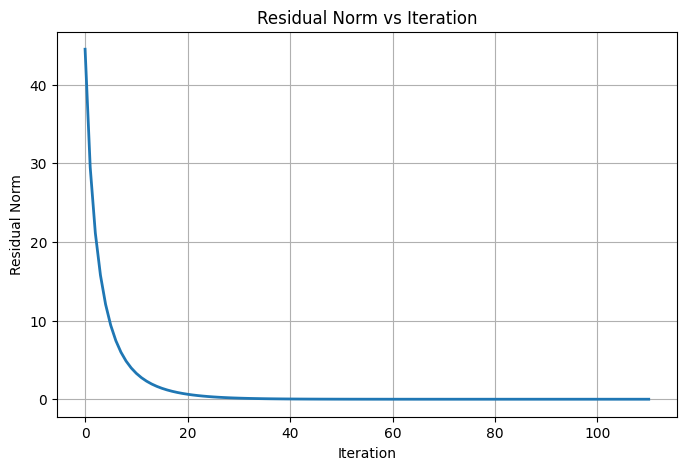

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# Generate Synthetic Least-Squares Problem
# ==========================================

np.random.seed(42)

m = 200      # Number of equations
n = 50       # Number of unknowns

A = np.random.randn(m, n)

# True solution
x_true = np.random.randn(n)

# Observation vector
b = A @ x_true

# ==========================================
# Compute Stable Learning Rate
# ==========================================

# Largest eigenvalue estimate of A^T A
L = np.linalg.norm(A, 2) ** 2

# Stable learning rate
alpha = 1.0 / L

print("=" * 50)
print("Gradient Descent Configuration")
print("=" * 50)
print(f"Matrix Size                : {m} x {n}")
print(f"Largest Eigenvalue (L)     : {L:.6f}")
print(f"Learning Rate (alpha)      : {alpha:.8f}")
print("=" * 50)

# ==========================================
# Gradient Descent Parameters
# ==========================================

max_iterations = 1000
tolerance = 1e-6

x = np.zeros(n)

loss_history = []
residual_history = []

# ==========================================
# Gradient Descent Algorithm
# ==========================================

start_time = time.time()

for iteration in range(max_iterations):

    gradient = A.T @ (A @ x - b)

    x = x - alpha * gradient

    residual = np.linalg.norm(A @ x - b)

    loss = 0.5 * residual ** 2

    loss_history.append(loss)
    residual_history.append(residual)

    # Check convergence
    if residual < tolerance:
        print(f"\nConverged after {iteration+1} iterations.")
        break

    # Detect divergence
    if np.isnan(loss) or np.isinf(loss):
        print("\nOptimization Diverged!")
        break

end_time = time.time()

# ==========================================
# Performance Metrics
# ==========================================

runtime = end_time - start_time

relative_error = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)

condition_number = np.linalg.cond(A)

print("\n")
print("=" * 50)
print("Experimental Results")
print("=" * 50)

print(f"Condition Number           : {condition_number:.6f}")
print(f"Iterations                 : {iteration+1}")
print(f"Residual Norm              : {residual:.8e}")
print(f"Relative Error             : {relative_error:.8e}")
print(f"Execution Time (seconds)   : {runtime:.6f}")

print("=" * 50)

# ==========================================
# Plot 1 : Objective Function
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(loss_history, linewidth=2)

plt.title("Gradient Descent Convergence")
plt.xlabel("Iteration")
plt.ylabel("Objective Function")

plt.grid(True)

plt.show()

# ==========================================
# Plot 2 : Residual Norm
# ==========================================

plt.figure(figsize=(8,5))
plt.plot(residual_history, linewidth=2)

plt.title("Residual Norm vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Residual Norm")

plt.grid(True)

plt.show()

Diagonal Scaling + Gradient Descent
Matrix Size                     : 200 x 50
Largest Eigenvalue Estimate     : 2.076360
Learning Rate                   : 0.48161213

Converged after 103 iterations.


Experimental Results
Original Condition Number      : 2.731138
Preconditioned Condition No.   : 7.041717
Iterations                     : 103
Residual Norm                  : 8.96357748e-07
Relative Error                 : 1.87022756e-08
Execution Time                 : 0.004198 seconds


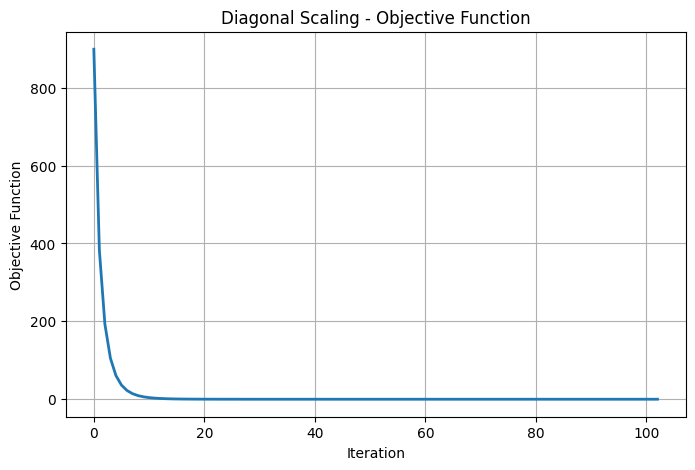

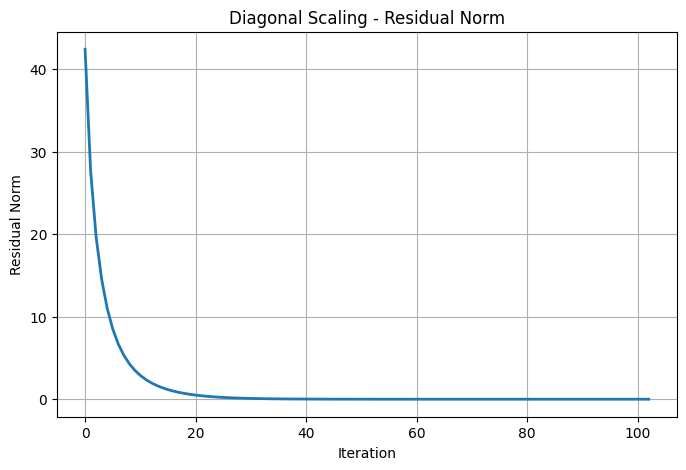

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================================
# EXPERIMENT 2
# Diagonal Scaling Preconditioning + Gradient Descent
# ==========================================================

# -----------------------------
# Generate Synthetic Dataset
# -----------------------------

np.random.seed(42)

m = 200
n = 50

A = np.random.randn(m, n)

# True solution
x_true = np.random.randn(n)

# Observation vector
b = A @ x_true

# -----------------------------
# Compute AᵀA
# -----------------------------

ATA = A.T @ A

# -----------------------------
# Diagonal Scaling Preconditioner
# -----------------------------

diag_entries = np.diag(ATA).copy()

diag_entries = np.maximum(diag_entries, 1e-12)

D_inv = np.diag(1.0 / diag_entries)

# -----------------------------
# Effective Matrix
# -----------------------------

B = D_inv @ ATA

# -----------------------------
# Stable Learning Rate
# -----------------------------

L = np.linalg.norm(B, 2)

alpha = 1.0 / L

print("="*60)
print("Diagonal Scaling + Gradient Descent")
print("="*60)

print(f"Matrix Size                     : {m} x {n}")
print(f"Largest Eigenvalue Estimate     : {L:.6f}")
print(f"Learning Rate                   : {alpha:.8f}")

print("="*60)

# -----------------------------
# Parameters
# -----------------------------

max_iterations = 1000
tolerance = 1e-6

x = np.zeros(n)

loss_history = []
residual_history = []

# -----------------------------
# Gradient Descent
# -----------------------------

start_time = time.time()

for iteration in range(max_iterations):

    gradient = A.T @ (A @ x - b)

    # Apply Diagonal Scaling
    gradient = D_inv @ gradient

    x = x - alpha * gradient

    residual = np.linalg.norm(A @ x - b)

    loss = 0.5 * residual**2

    loss_history.append(loss)
    residual_history.append(residual)

    if residual < tolerance:
        print(f"\nConverged after {iteration+1} iterations.")
        break

    if np.isnan(loss) or np.isinf(loss):
        print("\nOptimization Diverged!")
        break

end_time = time.time()

# -----------------------------
# Metrics
# -----------------------------

runtime = end_time - start_time

relative_error = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)

condition_original = np.linalg.cond(A)

condition_preconditioned = np.linalg.cond(B)

print("\n")
print("="*60)
print("Experimental Results")
print("="*60)

print(f"Original Condition Number      : {condition_original:.6f}")
print(f"Preconditioned Condition No.   : {condition_preconditioned:.6f}")
print(f"Iterations                     : {iteration+1}")
print(f"Residual Norm                  : {residual:.8e}")
print(f"Relative Error                 : {relative_error:.8e}")
print(f"Execution Time                 : {runtime:.6f} seconds")

print("="*60)

# -----------------------------
# Plot 1
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(loss_history, linewidth=2)

plt.title("Diagonal Scaling - Objective Function")

plt.xlabel("Iteration")

plt.ylabel("Objective Function")

plt.grid(True)

plt.show()

# -----------------------------
# Plot 2
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(residual_history, linewidth=2)

plt.title("Diagonal Scaling - Residual Norm")

plt.xlabel("Iteration")

plt.ylabel("Residual Norm")

plt.grid(True)

plt.show()

Iterative Preconditioning + Gradient Descent
Matrix Size                 : 200 x 50
Learning Rate               : 0.00228459

Converged after 131 iterations.

Experimental Results
Condition Number            : 2.731138
Iterations                  : 131
Residual Norm               : 9.96279555e-07
Relative Error              : 2.07597586e-08
Execution Time              : 0.005310 seconds


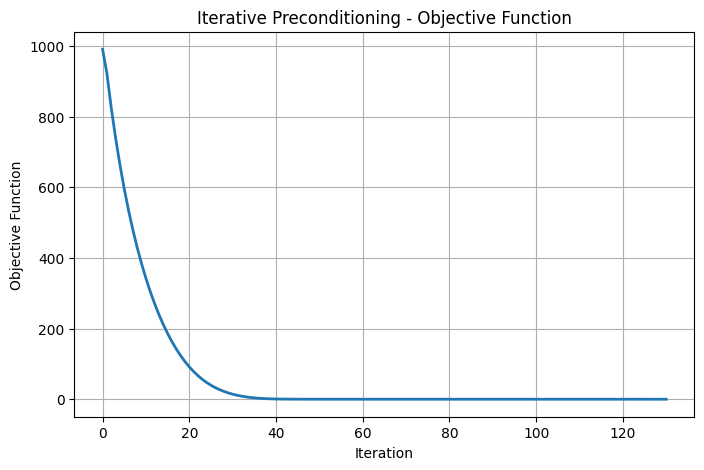

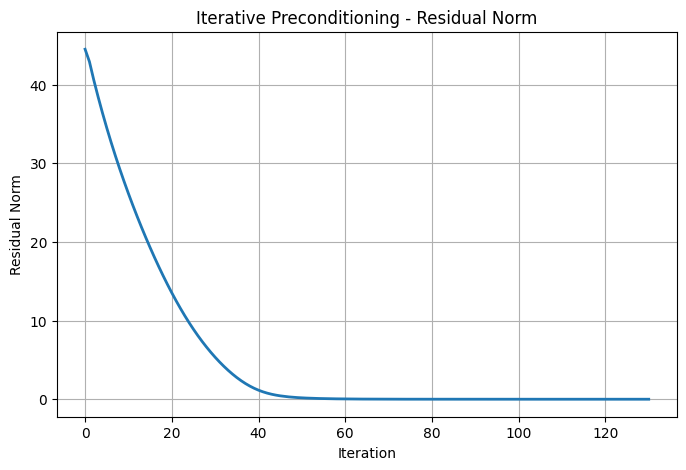

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================================
# EXPERIMENT 3
# Iterative Preconditioning + Gradient Descent
# ==========================================================

# -----------------------------
# Generate Synthetic Dataset
# -----------------------------

np.random.seed(42)

m = 200
n = 50

A = np.random.randn(m, n)

x_true = np.random.randn(n)

b = A @ x_true

ATA = A.T @ A

# -------------------------------------------------
# Initial Preconditioner
# -------------------------------------------------

P = np.eye(n)

# -------------------------------------------------
# Stable Learning Rate
# -------------------------------------------------

L = np.linalg.norm(ATA, 2)

alpha = 1.0 / L

print("="*60)
print("Iterative Preconditioning + Gradient Descent")
print("="*60)
print(f"Matrix Size                 : {m} x {n}")
print(f"Learning Rate               : {alpha:.8f}")
print("="*60)

# -------------------------------------------------
# Parameters
# -------------------------------------------------

max_iterations = 1000
tolerance = 1e-6

beta = 0.05          # preconditioner update rate

x = np.zeros(n)

loss_history = []
residual_history = []

start_time = time.time()

for iteration in range(max_iterations):

    gradient = A.T @ (A @ x - b)

    # Apply current preconditioner
    preconditioned_gradient = P @ gradient

    # Gradient update
    x = x - alpha * preconditioned_gradient

    # Update preconditioner
    diag_grad = np.abs(gradient)

    P = np.diag(1.0 / (1.0 + beta * diag_grad))

    residual = np.linalg.norm(A @ x - b)

    loss = 0.5 * residual**2

    loss_history.append(loss)
    residual_history.append(residual)

    if residual < tolerance:
        print(f"\nConverged after {iteration+1} iterations.")
        break

end_time = time.time()

runtime = end_time - start_time

relative_error = np.linalg.norm(x-x_true)/np.linalg.norm(x_true)

condition_number = np.linalg.cond(A)

print()
print("="*60)
print("Experimental Results")
print("="*60)
print(f"Condition Number            : {condition_number:.6f}")
print(f"Iterations                  : {iteration+1}")
print(f"Residual Norm               : {residual:.8e}")
print(f"Relative Error              : {relative_error:.8e}")
print(f"Execution Time              : {runtime:.6f} seconds")
print("="*60)

# -------------------------------------------------
# Plot Objective Function
# -------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(loss_history, linewidth=2)
plt.grid(True)
plt.title("Iterative Preconditioning - Objective Function")
plt.xlabel("Iteration")
plt.ylabel("Objective Function")
plt.show()

# -------------------------------------------------
# Plot Residual
# -------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(residual_history, linewidth=2)
plt.grid(True)
plt.title("Iterative Preconditioning - Residual Norm")
plt.xlabel("Iteration")
plt.ylabel("Residual Norm")
plt.show()

SVD Preconditioning + Gradient Descent
Matrix Size                 : 200 x 50
Largest Singular Value      : 20.921638
Smallest Singular Value     : 7.660410
Learning Rate               : 0.00228459

Converged after 918 iterations.

Experimental Results
Condition Number            : 2.731138
SVD Condition Number        : 2.731138
Iterations                  : 918
Residual Norm               : 9.92975072e-07
Relative Error              : 2.07366956e-08
Execution Time              : 0.076100 seconds


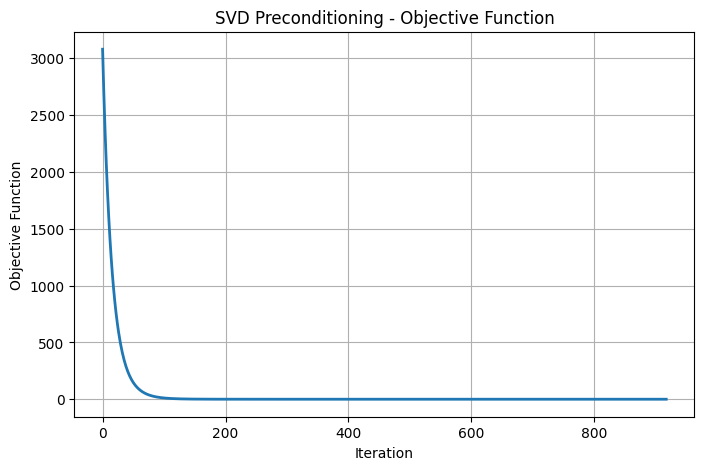

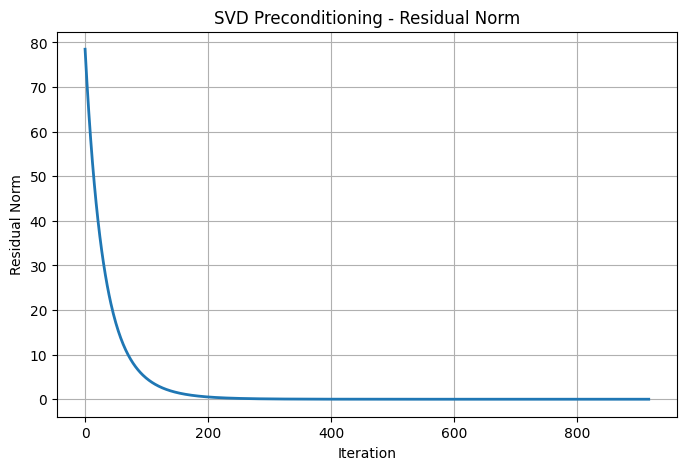

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================================
# EXPERIMENT 4
# SVD Preconditioning + Gradient Descent
# ==========================================================

# -----------------------------
# Generate Synthetic Dataset
# -----------------------------

np.random.seed(42)

m = 200
n = 50

A = np.random.randn(m, n)

x_true = np.random.randn(n)

b = A @ x_true

# -------------------------------------------------
# Singular Value Decomposition
# -------------------------------------------------

U, S, VT = np.linalg.svd(A, full_matrices=False)

# Construct inverse singular value matrix
S_inv = np.diag(1.0 / np.maximum(S, 1e-12))

# Pseudo-inverse based preconditioner
P = VT.T @ S_inv @ VT

# -------------------------------------------------
# Stable Learning Rate
# -------------------------------------------------

ATA = A.T @ A

L = np.linalg.norm(ATA, 2)

alpha = 1.0 / L

print("=" * 60)
print("SVD Preconditioning + Gradient Descent")
print("=" * 60)
print(f"Matrix Size                 : {m} x {n}")
print(f"Largest Singular Value      : {S.max():.6f}")
print(f"Smallest Singular Value     : {S.min():.6f}")
print(f"Learning Rate               : {alpha:.8f}")
print("=" * 60)

# -------------------------------------------------
# Parameters
# -------------------------------------------------

max_iterations = 1000
tolerance = 1e-6

x = np.zeros(n)

loss_history = []
residual_history = []

start_time = time.time()

for iteration in range(max_iterations):

    gradient = A.T @ (A @ x - b)

    # Apply SVD preconditioner
    gradient = P @ gradient

    x = x - alpha * gradient

    residual = np.linalg.norm(A @ x - b)

    loss = 0.5 * residual**2

    loss_history.append(loss)
    residual_history.append(residual)

    if residual < tolerance:
        print(f"\nConverged after {iteration + 1} iterations.")
        break

end_time = time.time()

runtime = end_time - start_time

relative_error = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)

condition_original = np.linalg.cond(A)

condition_svd = S.max() / S.min()

print()
print("=" * 60)
print("Experimental Results")
print("=" * 60)
print(f"Condition Number            : {condition_original:.6f}")
print(f"SVD Condition Number        : {condition_svd:.6f}")
print(f"Iterations                  : {iteration + 1}")
print(f"Residual Norm               : {residual:.8e}")
print(f"Relative Error              : {relative_error:.8e}")
print(f"Execution Time              : {runtime:.6f} seconds")
print("=" * 60)

# -------------------------------------------------
# Plot 1
# -------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(loss_history, linewidth=2)
plt.title("SVD Preconditioning - Objective Function")
plt.xlabel("Iteration")
plt.ylabel("Objective Function")
plt.grid(True)
plt.show()

# -------------------------------------------------
# Plot 2
# -------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(residual_history, linewidth=2)
plt.title("SVD Preconditioning - Residual Norm")
plt.xlabel("Iteration")
plt.ylabel("Residual Norm")
plt.grid(True)
plt.show()

Hilbert Matrix Size: 5
Hilbert Matrix Size: 10
Hilbert Matrix Size: 15
Hilbert Matrix Size: 20
   Size  Condition Number  GD Iterations  GD Residual  GD Relative Error  \
0     5      4.766073e+05          20000     0.000966           0.042469   
1    10      1.602442e+13          20000     0.000368           0.047387   
2    15      3.675683e+17          20000     0.001216           0.059142   
3    20      1.148402e+18          20000     0.002096           0.058872   

   GD Runtime  Diag Iterations  Diag Residual  Diag Relative Error  \
0    0.444588            20000       0.000470             0.018416   
1    0.498469            20000       0.000191             0.026294   
2    0.582898            20000       0.000662             0.035547   
3    0.498557            20000       0.001285             0.038321   

   Diag Runtime  SVD Residual  SVD Relative Error  SVD Runtime  
0      0.434067  2.666847e-15        1.156218e-12     0.000609  
1      0.496964  7.611306e-16        2.6876

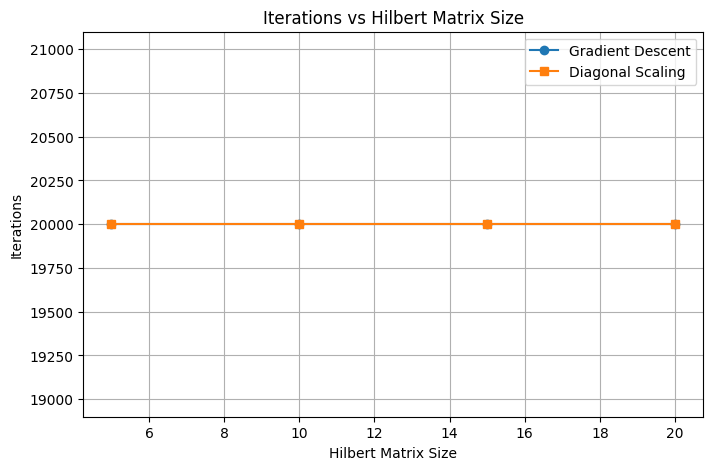

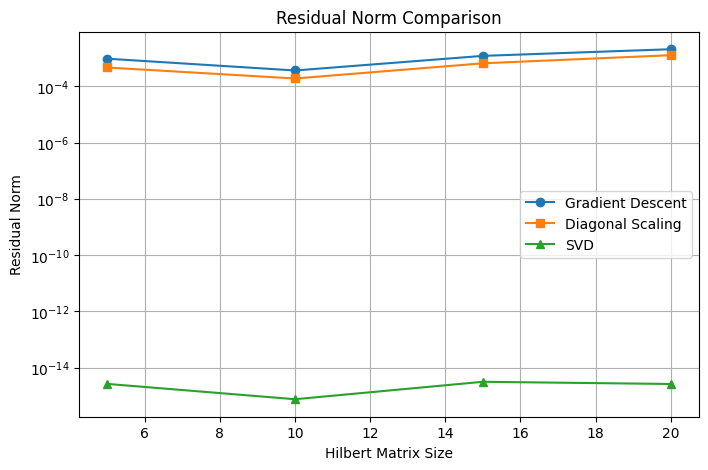

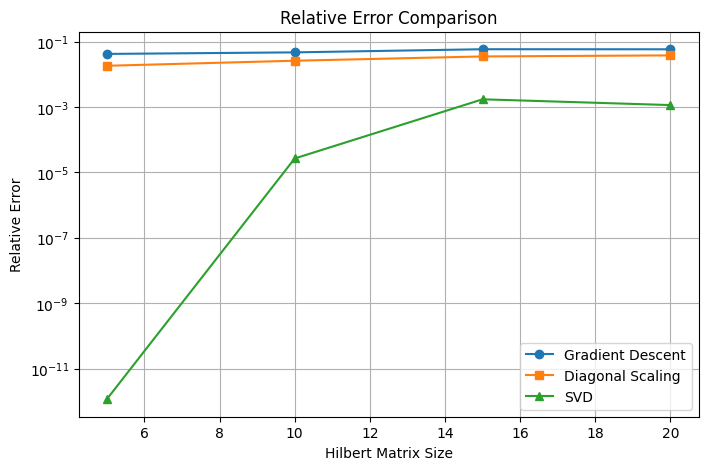

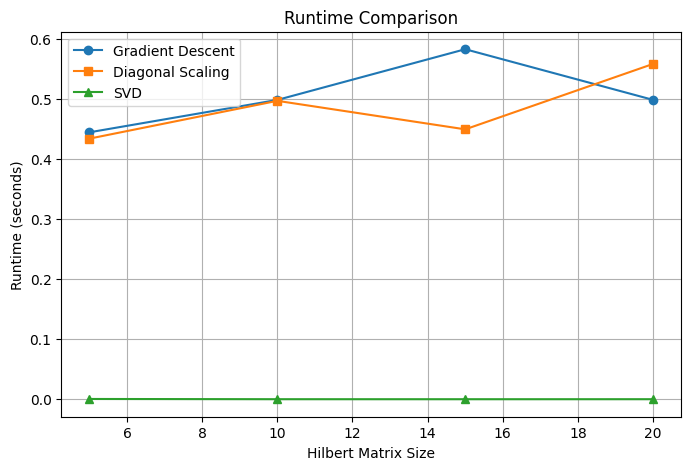


Experiment Completed Successfully.


In [ ]:
# ==========================================================
# EXPERIMENT 1: HILBERT MATRIX ANALYSIS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.linalg import hilbert

np.random.seed(42)

# ==========================================================
# Gradient Descent
# ==========================================================

def gradient_descent(A, b, tol=1e-8, max_iter=20000):

    # Lipschitz constant
    L = np.linalg.norm(A, 2) ** 2

    # Stable learning rate
    lr = 1.0 / L

    x = np.zeros(A.shape[1])

    start = time.time()

    for i in range(max_iter):

        gradient = A.T @ (A @ x - b)

        x_new = x - lr * gradient

        if np.linalg.norm(x_new - x) < tol:
            break

        x = x_new

    runtime = time.time() - start

    return x, i + 1, runtime

# ==========================================================
# Diagonal Scaling Gradient Descent
# ==========================================================

def diagonal_scaling_gd(A, b, tol=1e-8, max_iter=20000):

    x = np.zeros(A.shape[1])

    ATA = A.T @ A
    D = np.diag(1.0 / np.diag(ATA))

    # Stable learning rate
    L = np.linalg.norm(D @ ATA, 2)
    lr = 1.0 / L

    start = time.time()

    for i in range(max_iter):

        gradient = A.T @ (A @ x - b)

        x_new = x - lr * (D @ gradient)

        if np.linalg.norm(x_new - x) < tol:
            break

        x = x_new

    runtime = time.time() - start

    return x, i + 1, runtime


# ==========================================================
# SVD Solution
# ==========================================================

def svd_solution(A, b):

    start = time.time()

    # Stable least-squares solver using SVD internally
    x, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

    runtime = time.time() - start

    return x, runtime


# ==========================================================
# Metrics
# ==========================================================

def residual_norm(A,x,b):

    return np.linalg.norm(A@x-b)


def relative_error(x,x_true):

    return np.linalg.norm(x-x_true)/np.linalg.norm(x_true)


# ==========================================================
# Experiments
# ==========================================================

sizes = [5,10,15,20]

results=[]

for n in sizes:

    print("="*60)
    print("Hilbert Matrix Size:",n)

    A = hilbert(n)

    x_true = np.ones(n)

    b = A@x_true

    cond=np.linalg.cond(A)

    # --------------------------
    # Gradient Descent
    # --------------------------

    x_gd,it_gd,time_gd=gradient_descent(A,b)

    # --------------------------
    # Diagonal Scaling
    # --------------------------

    x_diag,it_diag,time_diag=diagonal_scaling_gd(A,b)

    # --------------------------
    # SVD
    # --------------------------

    x_svd,time_svd=svd_solution(A,b)

    results.append([

        n,

        cond,

        it_gd,

        residual_norm(A,x_gd,b),

        relative_error(x_gd,x_true),

        time_gd,

        it_diag,

        residual_norm(A,x_diag,b),

        relative_error(x_diag,x_true),

        time_diag,

        residual_norm(A,x_svd,b),

        relative_error(x_svd,x_true),

        time_svd

    ])


# ==========================================================
# DataFrame
# ==========================================================

columns=[

"Size",

"Condition Number",

"GD Iterations",

"GD Residual",

"GD Relative Error",

"GD Runtime",

"Diag Iterations",

"Diag Residual",

"Diag Relative Error",

"Diag Runtime",

"SVD Residual",

"SVD Relative Error",

"SVD Runtime"

]

df=pd.DataFrame(results,columns=columns)

print(df)

df.to_csv("Hilbert_Results.csv",index=False)

print("\nCSV Saved Successfully")


# ==========================================================
# Plot 1
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(df["Size"],df["GD Iterations"],marker='o',label="Gradient Descent")

plt.plot(df["Size"],df["Diag Iterations"],marker='s',label="Diagonal Scaling")

plt.xlabel("Hilbert Matrix Size")

plt.ylabel("Iterations")

plt.title("Iterations vs Hilbert Matrix Size")

plt.grid(True)

plt.legend()

plt.savefig("Figure1_Iterations.png",dpi=300)

plt.show()


# ==========================================================
# Plot 2
# ==========================================================

plt.figure(figsize=(8,5))

plt.semilogy(df["Size"],df["GD Residual"],marker='o',label="Gradient Descent")

plt.semilogy(df["Size"],df["Diag Residual"],marker='s',label="Diagonal Scaling")

plt.semilogy(df["Size"],df["SVD Residual"],marker='^',label="SVD")

plt.xlabel("Hilbert Matrix Size")

plt.ylabel("Residual Norm")

plt.title("Residual Norm Comparison")

plt.grid(True)

plt.legend()

plt.savefig("Figure2_Residual.png",dpi=300)

plt.show()


# ==========================================================
# Plot 3
# ==========================================================

plt.figure(figsize=(8,5))

plt.semilogy(df["Size"],df["GD Relative Error"],marker='o',label="Gradient Descent")

plt.semilogy(df["Size"],df["Diag Relative Error"],marker='s',label="Diagonal Scaling")

plt.semilogy(df["Size"],df["SVD Relative Error"],marker='^',label="SVD")

plt.xlabel("Hilbert Matrix Size")

plt.ylabel("Relative Error")

plt.title("Relative Error Comparison")

plt.grid(True)

plt.legend()

plt.savefig("Figure3_Error.png",dpi=300)

plt.show()


# ==========================================================
# Plot 4
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(df["Size"],df["GD Runtime"],marker='o',label="Gradient Descent")

plt.plot(df["Size"],df["Diag Runtime"],marker='s',label="Diagonal Scaling")

plt.plot(df["Size"],df["SVD Runtime"],marker='^',label="SVD")

plt.xlabel("Hilbert Matrix Size")

plt.ylabel("Runtime (seconds)")

plt.title("Runtime Comparison")

plt.grid(True)

plt.legend()

plt.savefig("Figure4_Runtime.png",dpi=300)

plt.show()


print("\nExperiment Completed Successfully.")

Matrix Size : 20
Matrix Size : 40
Matrix Size : 60
Matrix Size : 80
   Matrix Size  Condition Number  GD Iterations  GD Residual  \
0           20      1.000009e+12          20000     0.028057   
1           40      1.000010e+12          20000     0.046072   
2           60      9.999804e+11          20000     0.056090   
3           80      9.999994e+11          20000     0.046559   

   GD Relative Error  GD Runtime  DSGD Iterations  DSGD Residual  \
0           0.989170    0.549477            20000       0.004481   
1           0.884649    0.429546            20000       0.003317   
2           0.948386    0.566317            20000       0.004930   
3           0.925106    0.510273            20000       0.005887   

   DSGD Relative Error  DSGD Runtime  SVD Residual  SVD Relative Error  \
0             1.002602      0.404364  5.327378e-07            0.000002   
1             0.965628      0.447933  4.684479e-06            0.000005   
2             0.928898      0.742638  4.100760e-

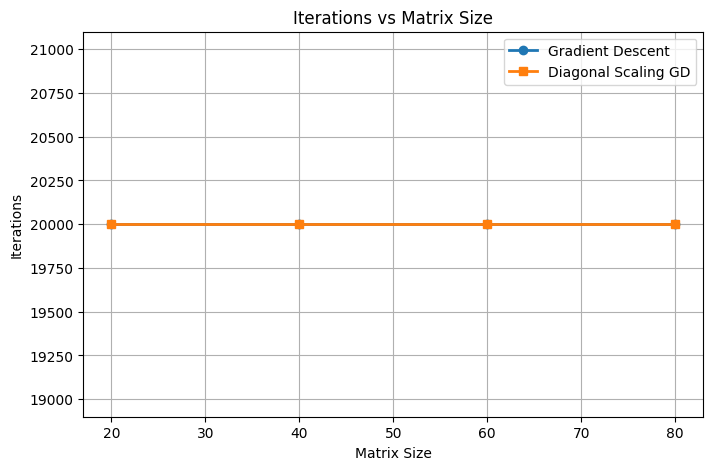

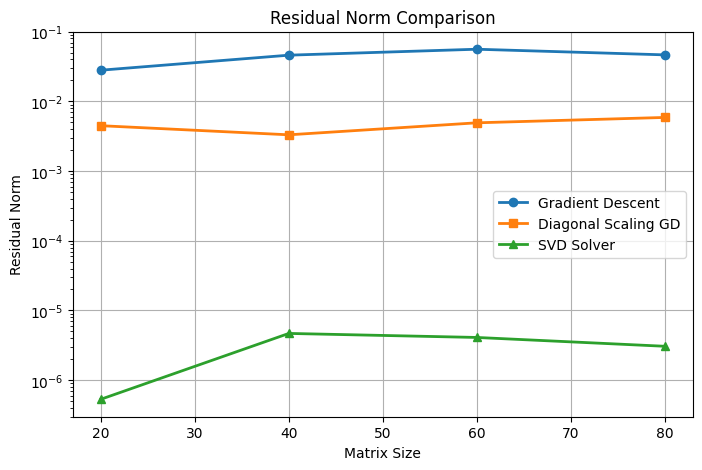

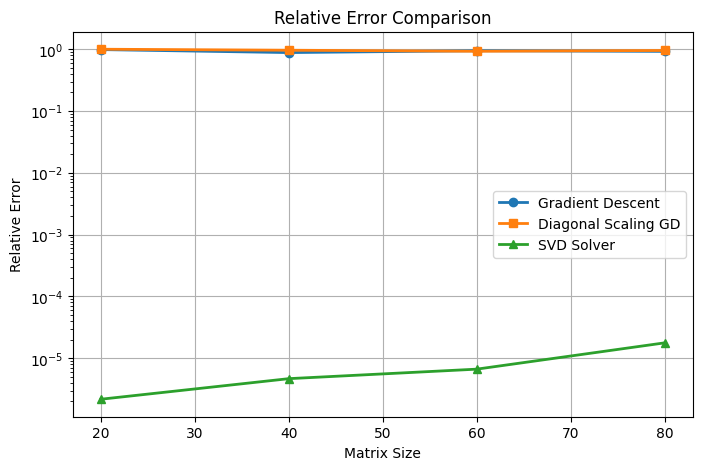

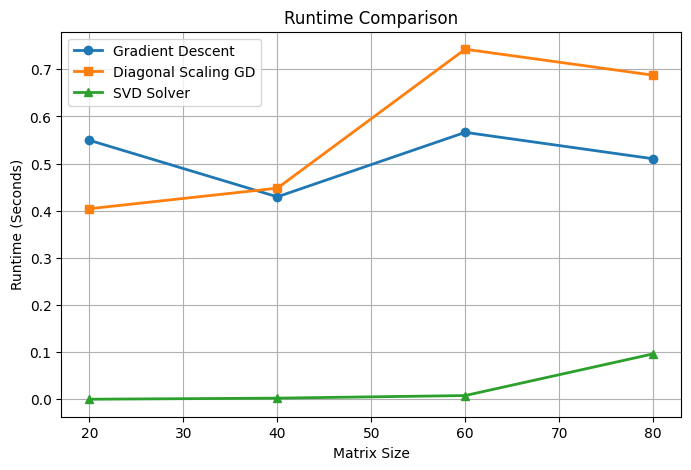


Experiment Completed Successfully.


In [ ]:
# ==========================================================
# EXPERIMENT 3 : RANDOM ILL-CONDITIONED MATRIX ANALYSIS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.stats import ortho_group

np.random.seed(42)

# ==========================================================
# Generate Random Ill-Conditioned Matrix
# ==========================================================

def generate_ill_conditioned_matrix(n, condition_number=1e12):

    U = ortho_group.rvs(dim=n)
    V = ortho_group.rvs(dim=n)

    singular_values = np.logspace(
        0,
        -np.log10(condition_number),
        n
    )

    S = np.diag(singular_values)

    A = U @ S @ V.T

    return A


# ==========================================================
# Gradient Descent
# ==========================================================

def gradient_descent(A, b, lr=0.01, tol=1e-8, max_iter=20000):

    x = np.zeros(A.shape[1])

    start = time.time()

    for i in range(max_iter):

        gradient = A.T @ (A @ x - b)

        x_new = x - lr * gradient

        if np.linalg.norm(x_new - x) < tol:
            break

        x = x_new

    runtime = time.time() - start

    return x, i + 1, runtime


# ==========================================================
# Diagonal Scaling GD
# ==========================================================

def diagonal_scaling_gd(A, b, lr=0.01, tol=1e-8, max_iter=20000):

    x = np.zeros(A.shape[1])

    ATA = A.T @ A

    D = np.diag(1 / np.diag(ATA))

    start = time.time()

    for i in range(max_iter):

        gradient = ATA @ x - A.T @ b

        x_new = x - lr * D @ gradient

        if np.linalg.norm(x_new - x) < tol:
            break

        x = x_new

    runtime = time.time() - start

    return x, i + 1, runtime


# ==========================================================
# SVD Solver
# ==========================================================

def svd_solver(A, b):

    start = time.time()

    U, S, VT = np.linalg.svd(A, full_matrices=False)

    x = VT.T @ np.diag(1 / S) @ U.T @ b

    runtime = time.time() - start

    return x, runtime


# ==========================================================
# Metrics
# ==========================================================

def residual(A, x, b):

    return np.linalg.norm(A @ x - b)


def relative_error(x, x_true):

    return np.linalg.norm(x - x_true) / np.linalg.norm(x_true)


# ==========================================================
# Experiment
# ==========================================================

sizes = [20, 40, 60, 80]

results = []

for n in sizes:

    print("=" * 70)
    print("Matrix Size :", n)

    A = generate_ill_conditioned_matrix(
        n,
        condition_number=1e12
    )

    x_true = np.ones(n)

    b = A @ x_true

    cond = np.linalg.cond(A)

    # -----------------------------
    # Gradient Descent
    # -----------------------------

    x_gd, it_gd, time_gd = gradient_descent(A, b)

    # -----------------------------
    # Diagonal Scaling GD
    # -----------------------------

    x_diag, it_diag, time_diag = diagonal_scaling_gd(A, b)

    # -----------------------------
    # SVD
    # -----------------------------

    x_svd, time_svd = svd_solver(A, b)

    results.append([

        n,

        cond,

        it_gd,

        residual(A, x_gd, b),

        relative_error(x_gd, x_true),

        time_gd,

        it_diag,

        residual(A, x_diag, b),

        relative_error(x_diag, x_true),

        time_diag,

        residual(A, x_svd, b),

        relative_error(x_svd, x_true),

        time_svd

    ])


# ==========================================================
# DataFrame
# ==========================================================

columns = [

    "Matrix Size",

    "Condition Number",

    "GD Iterations",

    "GD Residual",

    "GD Relative Error",

    "GD Runtime",

    "DSGD Iterations",

    "DSGD Residual",

    "DSGD Relative Error",

    "DSGD Runtime",

    "SVD Residual",

    "SVD Relative Error",

    "SVD Runtime"

]

df = pd.DataFrame(results, columns=columns)

print(df)

df.to_csv("Random_IllConditioned_Results.csv", index=False)

print("\nCSV Saved Successfully")


# ==========================================================
# Figure 9
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    df["Matrix Size"],
    df["GD Iterations"],
    marker='o',
    linewidth=2,
    label="Gradient Descent"
)

plt.plot(
    df["Matrix Size"],
    df["DSGD Iterations"],
    marker='s',
    linewidth=2,
    label="Diagonal Scaling GD"
)

plt.xlabel("Matrix Size")

plt.ylabel("Iterations")

plt.title("Iterations vs Matrix Size")

plt.grid(True)

plt.legend()

plt.savefig("Figure9_Iterations.png", dpi=300)

plt.show()


# ==========================================================
# Figure 10
# ==========================================================

plt.figure(figsize=(8,5))

plt.semilogy(
    df["Matrix Size"],
    df["GD Residual"],
    marker='o',
    linewidth=2,
    label="Gradient Descent"
)

plt.semilogy(
    df["Matrix Size"],
    df["DSGD Residual"],
    marker='s',
    linewidth=2,
    label="Diagonal Scaling GD"
)

plt.semilogy(
    df["Matrix Size"],
    df["SVD Residual"],
    marker='^',
    linewidth=2,
    label="SVD Solver"
)

plt.xlabel("Matrix Size")

plt.ylabel("Residual Norm")

plt.title("Residual Norm Comparison")

plt.grid(True)

plt.legend()

plt.savefig("Figure10_Residual.png", dpi=300)

plt.show()


# ==========================================================
# Figure 11
# ==========================================================

plt.figure(figsize=(8,5))

plt.semilogy(
    df["Matrix Size"],
    df["GD Relative Error"],
    marker='o',
    linewidth=2,
    label="Gradient Descent"
)

plt.semilogy(
    df["Matrix Size"],
    df["DSGD Relative Error"],
    marker='s',
    linewidth=2,
    label="Diagonal Scaling GD"
)

plt.semilogy(
    df["Matrix Size"],
    df["SVD Relative Error"],
    marker='^',
    linewidth=2,
    label="SVD Solver"
)

plt.xlabel("Matrix Size")

plt.ylabel("Relative Error")

plt.title("Relative Error Comparison")

plt.grid(True)

plt.legend()

plt.savefig("Figure11_Error.png", dpi=300)

plt.show()


# ==========================================================
# Figure 12
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    df["Matrix Size"],
    df["GD Runtime"],
    marker='o',
    linewidth=2,
    label="Gradient Descent"
)

plt.plot(
    df["Matrix Size"],
    df["DSGD Runtime"],
    marker='s',
    linewidth=2,
    label="Diagonal Scaling GD"
)

plt.plot(
    df["Matrix Size"],
    df["SVD Runtime"],
    marker='^',
    linewidth=2,
    label="SVD Solver"
)

plt.xlabel("Matrix Size")

plt.ylabel("Runtime (Seconds)")

plt.title("Runtime Comparison")

plt.grid(True)

plt.legend()

plt.savefig("Figure12_Runtime.png", dpi=300)

plt.show()

print("\nExperiment Completed Successfully.")